<a href="https://colab.research.google.com/github/Satvika1825/EmoTune-Emotion-Based-Music-Recommender/blob/main/EmoTune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow keras opencv-python

In [2]:
from google.colab import files
import zipfile, os

# Upload the FER-2013 zip file manually
uploaded = files.upload()

# Assuming your file name is fer2013.zip
zip_path = list(uploaded.keys())[0] # Get the name of the uploaded file
extract_path = "/content/fer2013"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted at:", extract_path)
print("📁 Folders:", os.listdir(extract_path))

Saving facial_emotions.zip to facial_emotions.zip
✅ Dataset extracted at: /content/fer2013
📁 Folders: ['test', 'train']


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [4]:
train_dir = os.path.join(extract_path, 'train')
val_dir = os.path.join(extract_path, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(96,96),  # upscale for VGG16
    color_mode="rgb",      # converts grayscale → 3 channels
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(96,96),
    color_mode="rgb",
    batch_size=32,
    class_mode='categorical'
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))

# Freeze base layers for feature extraction
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,078,087 (65.15 MB)

 Trainable params: 2,363,399 (9.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [6]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15  # initial top-layer training
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 104s 109ms/step - accuracy: 0.3248 - loss: 1.7482 - val_accuracy: 0.4312 - val_loss: 1.4549
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 92s 102ms/step - accuracy: 0.4002 - loss: 1.5516 - val_accuracy: 0.4592 - val_loss: 1.4100
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 92s 103ms/step - accuracy: 0.4181 - loss: 1.5113 - val_accuracy: 0.4720 - val_loss: 1.3810
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 92s 102ms/step - accuracy: 0.4238 - loss: 1.4964 - val_accuracy: 0.4720 - val_loss: 1.3767
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 92s 103ms/step - accuracy: 0.4315 - loss: 1.4796 - val_accuracy: 0.4763 - val_loss: 1.3846
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 93s 103ms/step - accuracy: 0.4353 - loss: 1.4627 - val_accuracy: 0.4850 - val_loss: 1.3531
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 92s 102ms/step - accuracy: 0.4463 - loss: 1.4434 - val_accuracy: 0.4865 - val_loss: 1.3539
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 92s 102ms/step - accuracy: 0.4467 - loss: 

In [7]:
# Unfreeze last 10 convolutional layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Callbacks
es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Compile with smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,  # fine-tuning
    callbacks=[es, rlr]
)


Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 122s 126ms/step - accuracy: 0.4782 - loss: 1.3646 - val_accuracy: 0.5284 - val_loss: 1.2224 - learning_rate: 1.0000e-05
Epoch 2/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 108s 120ms/step - accuracy: 0.5230 - loss: 1.2606 - val_accuracy: 0.5602 - val_loss: 1.1530 - learning_rate: 1.0000e-05
Epoch 3/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 108s 121ms/step - accuracy: 0.5473 - loss: 1.2079 - val_accuracy: 0.5612 - val_loss: 1.1456 - learning_rate: 1.0000e-05
Epoch 4/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 108s 120ms/step - accuracy: 0.5597 - loss: 1.1674 - val_accuracy: 0.5690 - val_loss: 1.1344 - learning_rate: 1.0000e-05
Epoch 5/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 109s 121ms/step - accuracy: 0.5816 - loss: 1.1157 - val_accuracy: 0.5986 - val_loss: 1.0537 - learning_rate: 1.0000e-05
Epoch 6/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 109s 121ms/step - accuracy: 0.5969 - loss: 1.0872 - val_accuracy: 0.6030 - val_loss: 1.0467 - learning_rate: 1.0000e-05
Epoch 7/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 

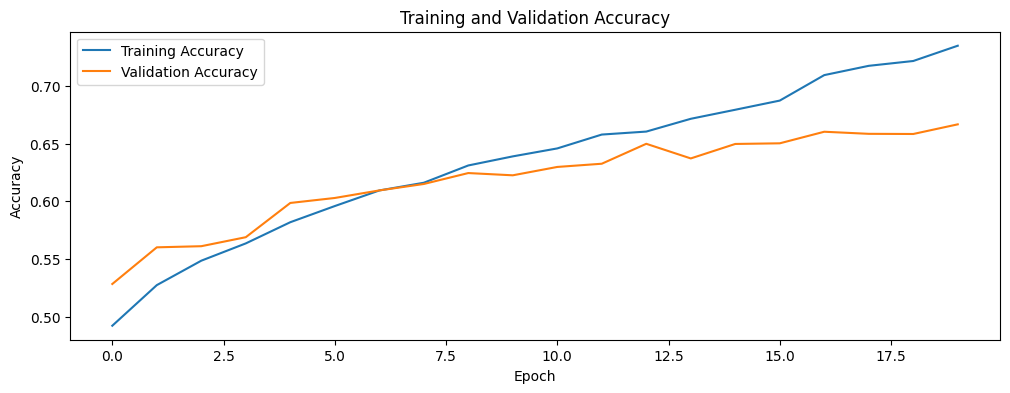

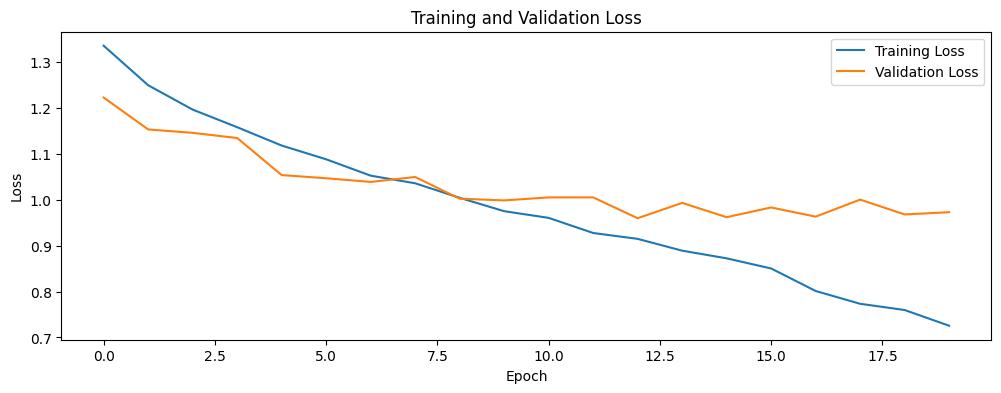

In [8]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.plot(history_fine.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 4))
plt.plot(history_fine.history['loss'], label='Training Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
model.save("fer2013_mobilenetv2.h5")
print("✅ Model saved successfully!")


✅ Model saved successfully!


In [11]:
from google.colab import files
files.download("fer2013_mobilenetv2.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving PublicTest_98276713.jpg to PublicTest_98276713.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


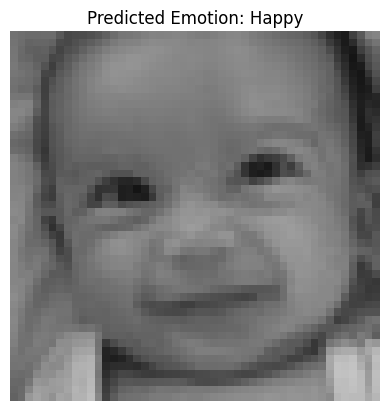

In [15]:
import numpy as np
import cv2
from google.colab import files
import matplotlib.pyplot as plt

# Define the emotion labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


# Upload an image
uploaded = files.upload()

# Get the first uploaded file
for filename in uploaded.keys():
    img_path = filename

# Load image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (96,96))   # Change to (48,48) or (224,224) if your model used that
img = img / 255.0
img = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(img)
pred_label = emotion_labels[np.argmax(pred)]

# Show result
plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted Emotion: {pred_label}")
plt.axis('off')
plt.show()